In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd


In [2]:
d1 = '/home/u0890475/Downloads/amr4_curv_combtest/plt75600_curvature.csv'
df = pd.read_csv(d1)

In [4]:
df['c'] = 1- df['Y(H2)']/ 0.012181

In [9]:
df

,x_grid,y_grid,z_grid,T,Q,P,rho,cp,Y(H2),lambda,k,Sd,gradT,flx,c
0,3740,366,8,298.848620,1.519035e+03,101324.989806,1.012901,1173.702134,0.011969,0.042859,-4584.411333,-0.521157,5.981208e+03,-3.158655e+03,0.017375
1,3740,366,9,298.818636,1.180450e+03,101324.992104,1.013142,1173.426267,0.011981,0.042871,-3976.144553,-0.376666,6.436025e+03,-2.457096e+03,0.016442
2,3740,367,8,298.901191,1.680392e+03,101324.989784,1.012652,1173.837973,0.011965,0.042859,-5055.539193,-0.598167,5.860540e+03,-3.551362e+03,0.017737
3,3740,367,9,298.877739,1.330692e+03,101324.991696,1.012875,1173.557504,0.011976,0.042871,-4444.051678,-0.463646,6.281531e+03,-2.951038e+03,0.016835
4,3740,367,10,298.831881,1.022653e+03,101324.992511,1.013155,1173.303307,0.011988,0.042882,-3921.489173,-0.319439,6.729059e+03,-2.178673e+03,0.015874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4003587,4126,1023,29,751.436719,2.828578e+09,101321.506943,0.421926,1220.428678,0.005950,0.078314,-12507.468586,0.005696,1.232118e+07,-2.288081e+06,0.511544
4003588,4126,1023,30,617.122577,1.967592e+09,101320.798264,0.512167,1184.633663,0.006987,0.067694,-15838.562783,-0.401389,8.751345e+06,-3.460014e+06,0.426366
4003589,4126,1023,31,617.122577,1.967592e+09,101320.798264,0.512167,1184.633663,0.006987,0.067694,-16227.660526,-0.216495,9.325994e+06,-2.695009e+06,0.426366
4003590,4126,1023,32,443.409535,4.455124e+08,101328.924322,0.706354,1154.287719,0.008624,0.053750,30195.217941,9.115231,6.889337e+06,4.397162e+07,0.292034


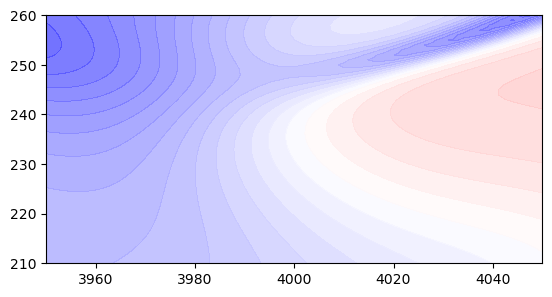

In [11]:
df2 = df[(df['x_grid']>=3950) & (df['x_grid']<=4050) &(df['y_grid']>=210) &(df['y_grid']<=260) &(df['z_grid']==1)]
divu_grid=df2.pivot_table(
    index='y_grid',
    columns='x_grid',
    values='k',
    aggfunc='median',
)
levels=np.linspace(-20000,20000,41,)
vmin=-20000
vmax=20000
X=divu_grid.columns.values
Y=divu_grid.index.values
Z=divu_grid.values
fig,ax = plt.subplots()
ax.set_aspect('equal')
cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 )

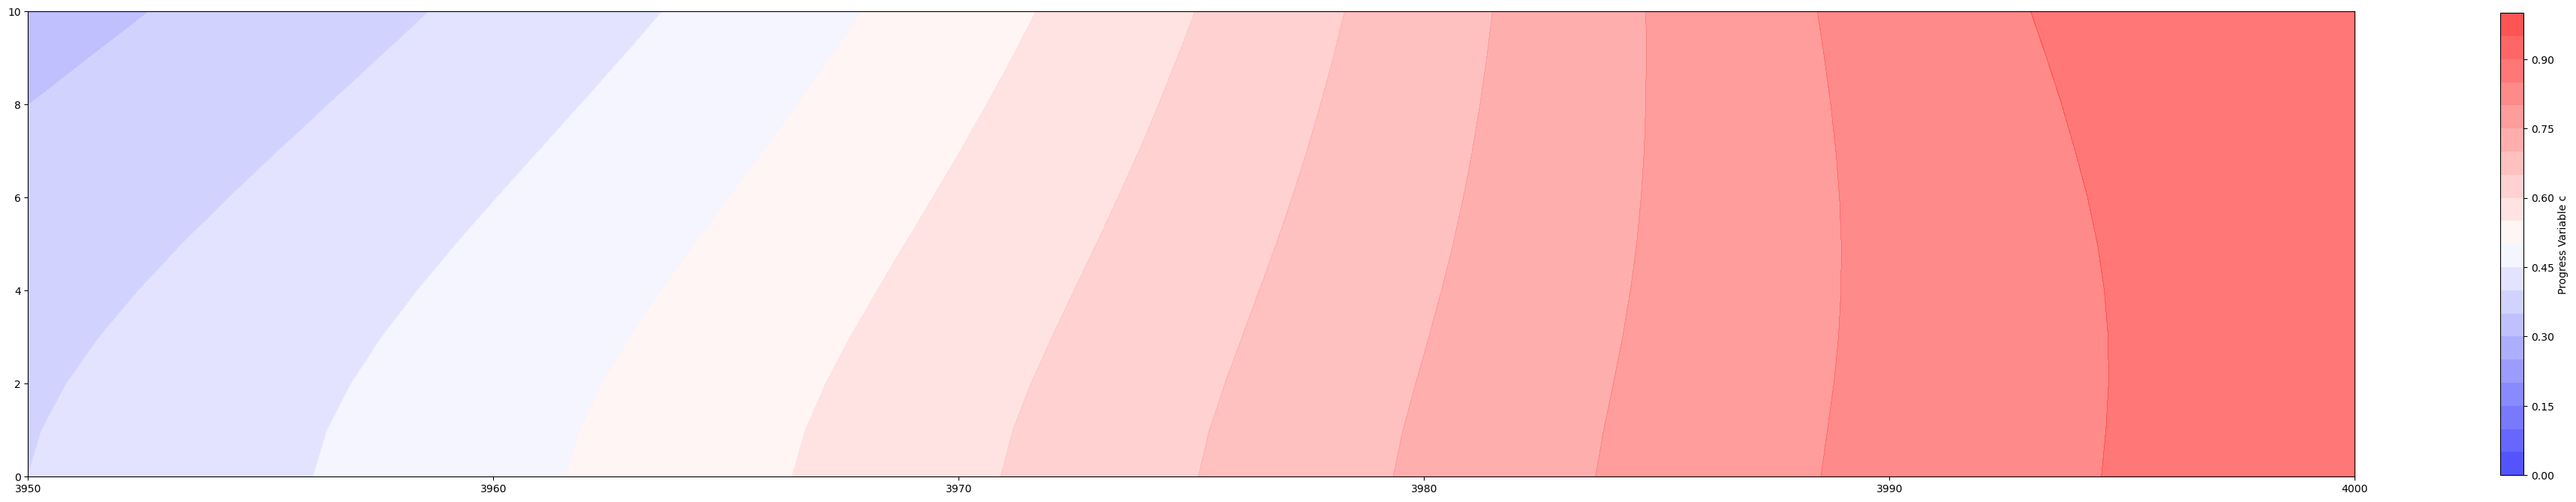

In [112]:
yslice = 245
df_slice = df[(df['y_grid']==yslice ) & (df['z_grid']<=10)  & (df['x_grid']>=3950) & (df['x_grid']<=4000)  ]
slice_grid=df_slice.pivot_table(
    index='z_grid',
    columns='x_grid',
    values='c',
    aggfunc='median',
)
levels=np.linspace(0,1,21,)
vmin=0
vmax=1
X=slice_grid.columns.values
Y=slice_grid.index.values
Z=slice_grid.values
fig,ax = plt.subplots(figsize=(50,80))
ax.set_aspect('equal')

cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 )
cbar =plt.colorbar(cf,shrink=0.1,ax=ax,label='Progress Variable c')
plt.savefig(f'plt75600_c_slice_y={yslice}.png',dpi=600)

In [ ]:
yslice = 245
df_sliceT = df[(df['y_grid']==yslice ) & (df['z_grid']<=10)  & (df['x_grid']>=3950) & (df['x_grid']<=4000)  ]
Tslice_grid=df_sliceT.pivot_table(
    index='z_grid',
    columns='x_grid',
    values='T',
    aggfunc='median',
)

vmin=290
vmax=1500
levels=np.linspace(vmin,vmax,81,)
X=Tslice_grid.columns.values
Y=Tslice_grid.index.values
Z=Tslice_grid.values
fig,ax = plt.subplots(figsize=(50,80))
ax.set_aspect('equal')

cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 )
cbar =plt.colorbar(cf,shrink=0.1,ax=ax,label='Progress Variable c')
plt.savefig(f'plt75600_T_slice_y={yslice}.png',dpi=600)

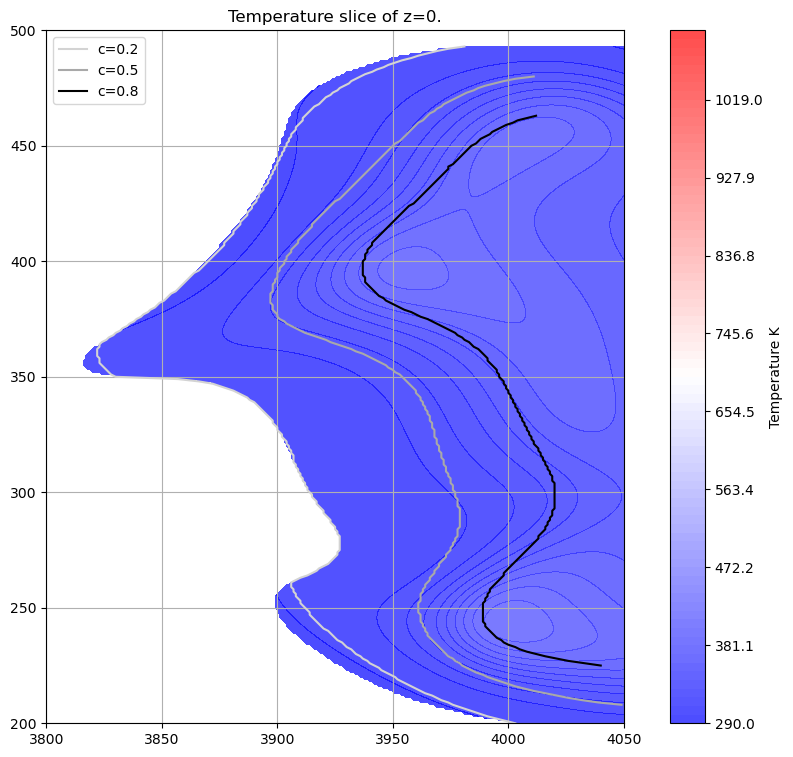

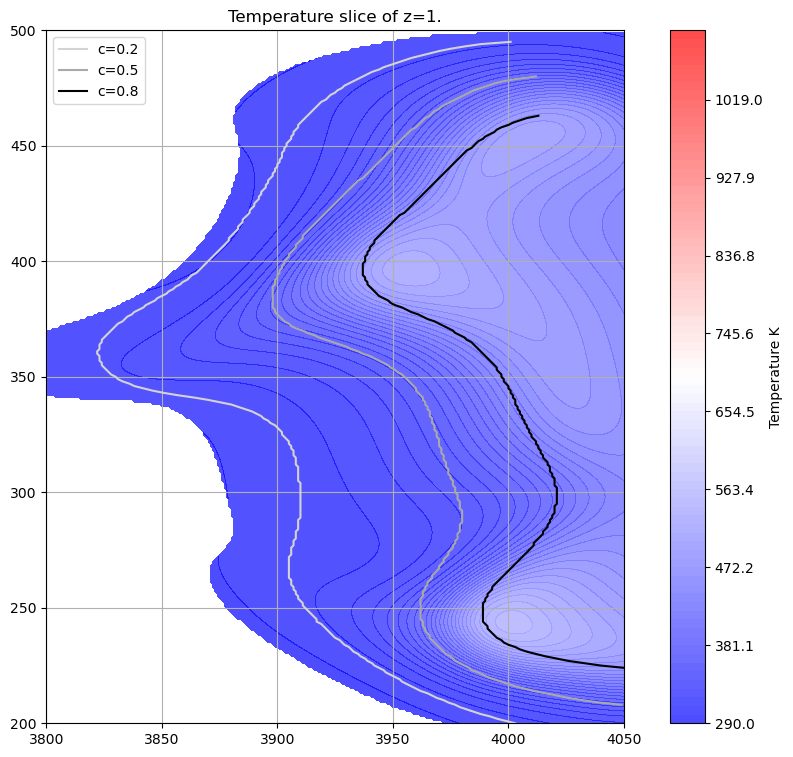

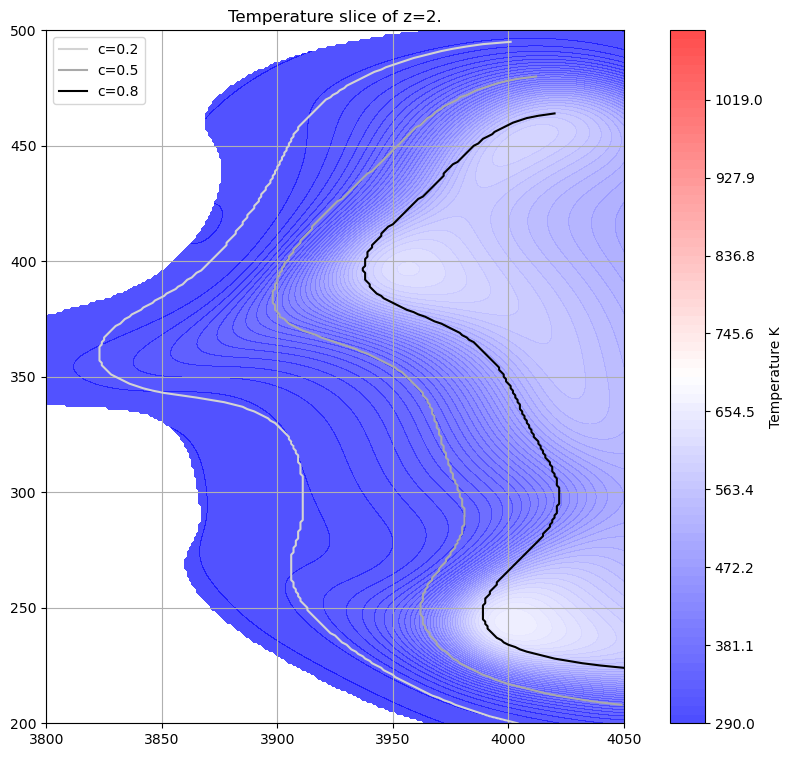

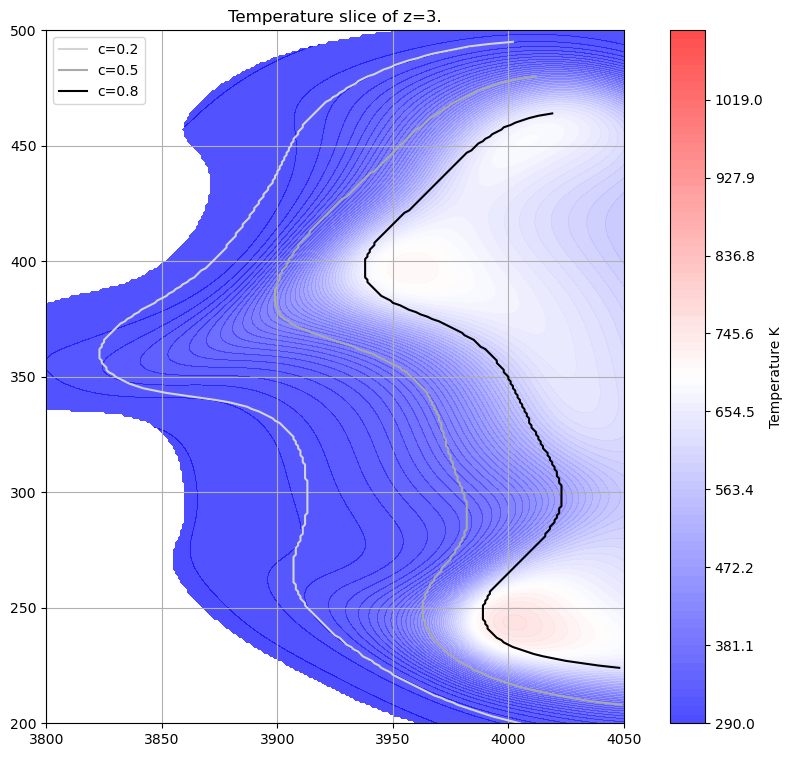

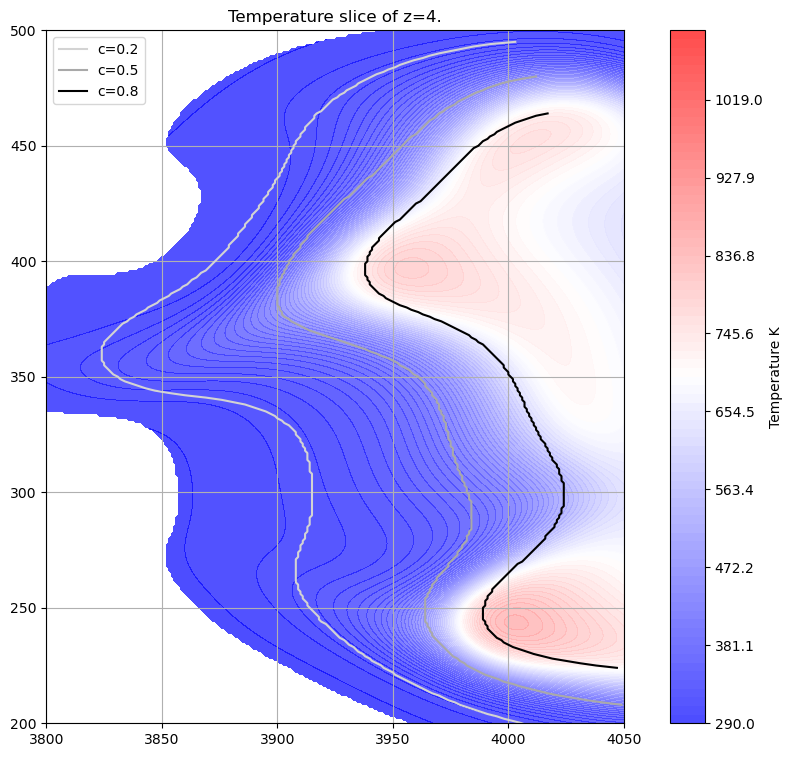

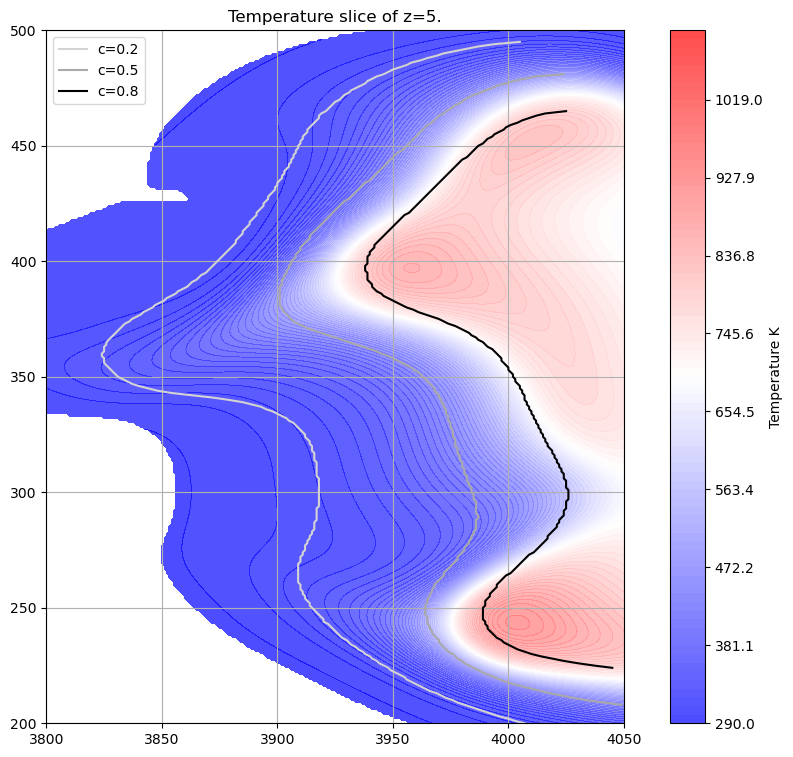

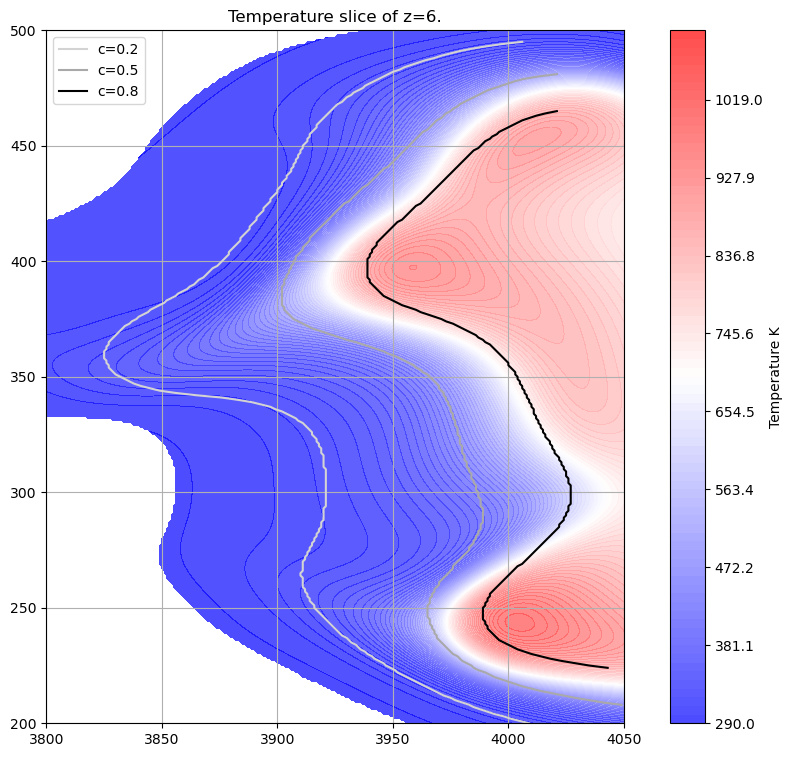

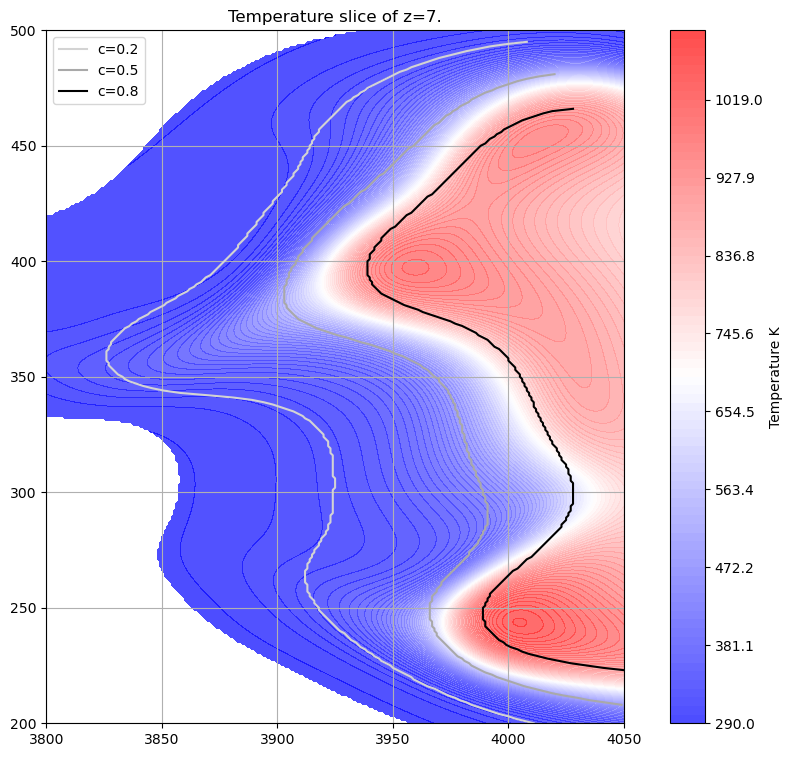

In [102]:
for i in range(0,8):
    df_s2= df[(df['z_grid']==i) & (df['x_grid']<=4050) & (df['x_grid']>=3750)& (df['y_grid']<=500)&(df['y_grid']>=200)  ].copy()
    df_sr_vc02 = df_s2[df_s2['c']>=0.2]
    df_sr_vc05 = df_s2[df_s2['c']>=0.5]
    df_sr_vc08 = df_s2[df_s2['c']>=0.8]
    df_sr_vc02minx   = df_sr_vc02.loc[df_sr_vc02.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc05minx   = df_sr_vc05.loc[df_sr_vc05.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc08minx   = df_sr_vc08.loc[df_sr_vc08.groupby('y_grid')['x_grid'].idxmin()].copy()
    slice_grid=df_s2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='T',
        aggfunc='median',
    )
    
    vmin=290
    vmax=1100
    levels=np.linspace(vmin,vmax,81,)
    X=slice_grid.columns.values
    Y=slice_grid.index.values
    Z=slice_grid.values
    fig,ax = plt.subplots(figsize=(12,9))
    ax.set_aspect('equal')
    
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 )
    cbar =plt.colorbar(cf,ax=ax,label='Temperature K')
    ax.set_title(f'Temperature slice of z={i}.')
    ax.plot(df_sr_vc02minx['x_grid'],df_sr_vc02minx['y_grid'], label='c=0.2',color ='lightgray' )
    ax.plot(df_sr_vc05minx['x_grid'],df_sr_vc05minx['y_grid'], label='c=0.5',color ='darkgray' )
    ax.plot(df_sr_vc08minx['x_grid'],df_sr_vc08minx['y_grid'], label='c=0.8',color ='black' )
    ax.legend()
    ax.set_ylim(200,500)
    ax.set_xlim(3800,4050)
    ax.grid()
    plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt75600_Hrz_TempSlice_z={i}.png',dpi=600)
    

In [94]:
df[(df['x_grid']>=3915) & (df['x_grid']<=3925) & (df['y_grid']>=270) & (df['y_grid']<=280) & (df['z_grid']==1) ]

,x_grid,y_grid,z_grid,T,Q,P,rho,cp,Y(H2),lambda,k,Sd,gradT,flx,c
584613,3915,270,1,305.536814,125415.542744,101324.897149,0.993171,1182.803793,0.009351,0.040584,-15529.669852,0.425739,280403.873725,118457.578055,0.232362
584646,3915,271,1,305.318905,122019.611913,101324.897865,0.993755,1182.924150,0.009363,0.040574,-15354.291733,0.423839,272091.552014,114499.662910,0.231375
584679,3915,272,1,305.127679,119006.088078,101324.897906,0.994250,1183.046809,0.009375,0.040568,-15175.412500,0.421570,264764.178191,110874.213491,0.230329
584712,3915,273,1,304.962951,116372.642360,101324.897877,0.994655,1183.176908,0.009389,0.040564,-14999.477210,0.418971,258418.484645,107592.843263,0.229245
584745,3915,274,1,304.824006,114110.926741,101324.897422,0.994969,1183.318476,0.009402,0.040564,-14831.098306,0.416093,253030.211331,104658.073236,0.228140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664361,3925,276,1,306.105331,134033.452411,101324.854897,0.992649,1182.078156,0.009068,0.040332,-13976.202101,0.402314,298464.950516,119080.579216,0.255582
664390,3925,277,1,306.060308,132507.073348,101324.853126,0.992613,1182.286467,0.009083,0.040344,-13876.329367,0.399461,296619.866241,117500.704988,0.254310
664419,3925,278,1,306.039612,131393.082756,101324.856523,0.992489,1182.516950,0.009098,0.040357,-13793.257807,0.396484,295668.997972,116236.319098,0.253129
664446,3925,279,1,306.039620,130664.611265,101324.852870,0.992290,1182.767770,0.009111,0.040370,-13730.959225,0.393936,295471.741546,115389.166099,0.252049


In [135]:
df['Sd'].min()

-7.94847695979012

In [137]:
df

,x_grid,y_grid,z_grid,T,Q,P,rho,cp,Y(H2),lambda,k,Sd,gradT,flx,c
77745,3822,360,1,306.649441,9.280172e+04,101324.902968,0.976644,1201.654441,0.009743,0.041050,-14558.618624,0.436815,3.255987e+05,1.388273e+05,0.799877
77788,3822,361,1,306.311721,8.920618e+04,101324.902866,0.978594,1200.209461,0.009745,0.041023,-14493.373368,0.435726,3.128283e+05,1.333153e+05,0.799982
80512,3823,357,1,307.629572,1.035424e+05,101324.907687,0.971284,1205.455798,0.009730,0.041123,-12892.788293,0.441002,3.628543e+05,1.553384e+05,0.798802
80513,3823,357,2,313.653940,9.468160e+04,101324.880726,0.953148,1205.065874,0.009740,0.041788,-11873.225342,-0.155626,3.408550e+05,-5.063926e+04,0.799602
80555,3823,358,1,307.432089,1.016398e+05,101324.904827,0.972564,1204.426368,0.009718,0.041093,-13760.712724,0.439219,3.551688e+05,1.516324e+05,0.797829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4507511,4115,839,7,1286.502868,3.844771e+09,101325.157029,0.242200,1359.511284,0.002529,0.124678,-499.890992,1.039693,2.495900e+06,-2.199551e+06,0.207644
4507535,4115,840,7,1288.362588,3.836680e+09,101325.159456,0.241824,1359.682144,0.002515,0.124848,-521.999750,1.039438,2.474997e+06,-2.199631e+06,0.206453
4507559,4115,841,7,1290.495791,3.825415e+09,101325.159639,0.241398,1359.844012,0.002497,0.125035,-544.640996,1.038538,2.450637e+06,-2.198750e+06,0.204987
4507583,4115,842,7,1292.887403,3.811100e+09,101325.164871,0.240928,1359.994564,0.002476,0.125241,-568.051477,1.036971,2.422998e+06,-2.196940e+06,0.203260
